In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load data
data_path = "autodl-tmp/Anonymizing_suicide_datasets.csv"
df = pd.read_csv(data_path)

# Ensure time column is datetime format, and sort by user and time
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by=['users', 'time']).reset_index(drop=True)

# Basic processing of text features
df['text'] = df['text'].fillna('').astype(str)
df['text_length'] = df['text'].apply(len)
df['hour'] = df['time'].dt.hour
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 22 or x <= 4) else 0)

print(f"Total number of original posts: {len(df)}")

Total number of original posts: 14613


In [3]:
user_features = []

# Iterate through each user and construct features using a sliding window
for user, group in df.groupby('users'):
    group = group.reset_index(drop=True)
    # Pre-calculate the time intervals for all posts of the user
    group['time_diff'] = group['time'].diff().dt.total_seconds() / 3600
    group['time_diff'] = group['time_diff'].fillna(0)
    
    for i in range(len(group)):
        # Extract the current post and trace back up to 4 historical posts (forming a stable 5-element window)
        window_start = max(0, i - 4)
        window_df = group.iloc[window_start:i+1]
        
        # The target label is the sentiment of the latest current post
        label = window_df['sentiment'].iloc[-1]
        
        # Concatenate text within the window for TF-IDF
        combined_text = " ".join(window_df['text'].tolist())
        
        # Aggregate behavioral features
        avg_time_diff = window_df['time_diff'].mean()
        night_post_ratio = window_df['is_night'].mean() 
        avg_text_length = window_df['text_length'].mean()
        length_std = window_df['text_length'].std() if len(window_df) > 1 else 0 
        post_count = len(window_df) 
        
        user_features.append({
            'users': user,
            'combined_text': combined_text,
            'avg_time_diff': avg_time_diff,
            'night_post_ratio': night_post_ratio,
            'avg_text_length': avg_text_length,
            'length_std': length_std,
            'post_count': post_count,
            'label': label
        })

df_users = pd.DataFrame(user_features)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=150, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_users['combined_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{i}' for i in range(150)])

# Concatenate all features
df_final = pd.concat([df_users.drop(columns=['combined_text']), tfidf_df], axis=1)

# Label encoding
le = LabelEncoder()
df_final['label_encoded'] = le.fit_transform(df_final['label'])

print(f"Sliding window feature construction completed, total number of samples: {len(df_final)}")

Sliding window feature construction completed, total number of samples: 14613


In [4]:
# Get a list of unique users
unique_users = df_final['users'].unique()

# Step 1: Split 80% training set and 20% temporary set (including validation + test)
train_users, temp_users = train_test_split(unique_users, test_size=0.20, random_state=42)

# Step 2: Split the 20% temporary set equally into 10% validation set and 10% test set
val_users, test_users = train_test_split(temp_users, test_size=0.50, random_state=42)

print(f"Split by user -> Training set users: {len(train_users)}, Validation set users: {len(val_users)}, Test set users: {len(test_users)}")

# Split DataFrame according to the partitioned user IDs
train_df = df_final[df_final['users'].isin(train_users)]
val_df = df_final[df_final['users'].isin(val_users)]
test_df = df_final[df_final['users'].isin(test_users)]

print(f"Sample distribution -> Training set: {len(train_df)} rows, Validation set: {len(val_df)} rows, Test set: {len(test_df)} rows")

# Prepare X and y
drop_cols = ['users', 'label', 'label_encoded']
X_train, y_train = train_df.drop(columns=drop_cols), train_df['label_encoded']
X_val, y_val = val_df.drop(columns=drop_cols), val_df['label_encoded']
X_test, y_test = test_df.drop(columns=drop_cols), test_df['label_encoded']

# Calculate sample weights to reverse extreme class imbalance (very important!)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

Split by user -> Training set users: 1012, Validation set users: 126, Test set users: 127
Sample distribution -> Training set: 12334 rows, Validation set: 1114 rows, Test set: 1165 rows


In [5]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05, 
    objective='multi:softmax', 
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("Starting to train XGBoost model...")
# Use the validation set for monitoring, stop early if the validation loss doesn't decrease for 20 rounds
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

Starting to train XGBoost model...
[0]	validation_0-mlogloss:1.13703	validation_1-mlogloss:1.14055
[50]	validation_0-mlogloss:0.87711	validation_1-mlogloss:1.06036
[100]	validation_0-mlogloss:0.77605	validation_1-mlogloss:1.04580
[150]	validation_0-mlogloss:0.71156	validation_1-mlogloss:1.04422
[200]	validation_0-mlogloss:0.66281	validation_1-mlogloss:1.04535
[250]	validation_0-mlogloss:0.62294	validation_1-mlogloss:1.04547
[299]	validation_0-mlogloss:0.58920	validation_1-mlogloss:1.04748


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [6]:
# Predict on the completely independent test set
test_preds = xgb_model.predict(X_test)

# Calculate overall Acc and Mac-F1
acc = accuracy_score(y_test, test_preds)
mac_f1 = f1_score(y_test, test_preds, average='macro')

# Get F1 scores for each class
class_f1s = f1_score(y_test, test_preds, average=None)
class_names = le.classes_
f1_dict = {class_names[i]: class_f1s[i] for i in range(len(class_names))}

print("\n" + "="*30)
print("XGBoost Test Set Results:")
print(f"Acc. (%): {acc * 100:.1f}")
print(f"Mac-F1 (%): {mac_f1 * 100:.1f}")
print(f"IN-F1 (%): {f1_dict.get('Indicator', 0) * 100:.1f}")
print(f"ID-F1 (%): {f1_dict.get('Ideation', 0) * 100:.1f}")
print(f"BR-F1 (%): {f1_dict.get('Behavior', 0) * 100:.1f}")
print(f"AT-F1 (%): {f1_dict.get('Attempt', 0) * 100:.1f}")
print("="*30)


XGBoost Test Set Results:
Acc. (%): 54.0
Mac-F1 (%): 31.2
IN-F1 (%): 44.8
ID-F1 (%): 66.8
BR-F1 (%): 10.6
AT-F1 (%): 2.6


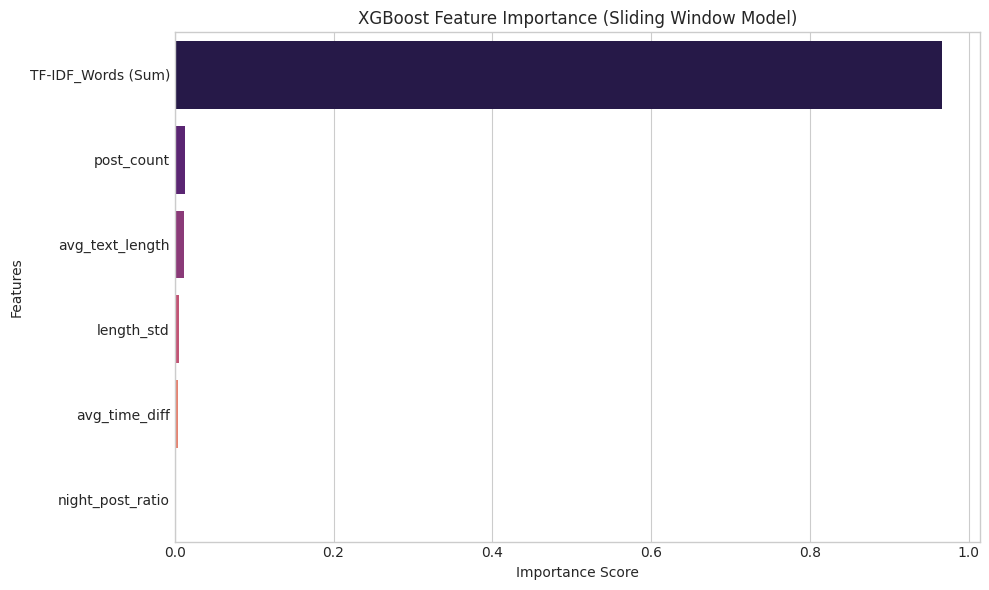

In [7]:
# Extract feature importances
feature_importances = xgb_model.feature_importances_
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Merge TF-IDF features to simplify the chart (prevent bag-of-words features from dominating)
tfidf_importance = fi_df[fi_df['Feature'].str.startswith('tfidf_')]['Importance'].sum()
fi_df_clean = fi_df[~fi_df['Feature'].str.startswith('tfidf_')].copy()
fi_df_clean.loc[len(fi_df_clean)] = ['TF-IDF_Words (Sum)', tfidf_importance]

# Sort and select the top 15 important features
fi_df_clean = fi_df_clean.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_clean, palette='magma')
plt.title('XGBoost Feature Importance (Sliding Window Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()